# Backtest 005 — TTM Breakout Squeeze

Notebook implementation of `BreakoutTTMVersion2` from `backend/app/services/strategies/breakout_ttm.py`.

## Strategy logic

| Version | Entry condition |
|---------|----------------|
| **v1** | `no_squeeze` AND `TTM momentum > 0` |
| **v2** | `no_squeeze` AND `TTM momentum crossed above 0` (up to 3 bars look-back) |
| **v3** | Squeeze JUST released AND (`momentum > 0` OR `consecutive_neg > threshold`) OR Williams VIX Fix signal |

**Exit:** ATR trailing stop (multiplier optimised via Optuna)

**Optimisation:** Multi-objective Optuna — maximise `Total Return (%)` and `Sortino Ratio`

In [97]:
import warnings
warnings.filterwarnings('ignore')

import os, sys, pathlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numba as nb
import vectorbt as vbt
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

sys.path.insert(0, str(pathlib.Path('..').resolve()))
from backend.app.services.indicators.trailing_sl import atr_trailing_nb
from backend.app.services.indicators.wiliams_vix_fix import williams_vix_fix_indicator

plt.style.use('dark_background')
print('imports ok')

imports ok


## 1. Load Data

In [98]:
REMOTE_HOST = 'http://192.168.1.30:9000'

def load_stock_data() -> pd.DataFrame:
    from deltalake import DeltaTable
    storage_options = {
        'AWS_ACCESS_KEY_ID':          'CzOwnLkEDXQy951AOqes',
        'AWS_SECRET_ACCESS_KEY':      'fdRe91TOtqTl0icUkZLsUnWvZa90aZ5qG5rVEf7S',
        'AWS_ENDPOINT_URL':           REMOTE_HOST,
        'AWS_ALLOW_HTTP':             'true',
        'AWS_EC2_METADATA_DISABLED':  'true',
        'AWS_REGION':                 'us-east-1',
        'aws_conditional_put':        'etag',
    }
    watchlist_df      = pd.read_csv('../backend/models/watchlist.csv')
    watchlist_symbols = watchlist_df.iloc[:, 0].values
    start_date        = pd.Timestamp.now() - pd.DateOffset(years=10)

    dt = DeltaTable('s3://delta-table-storage/stocks', storage_options=storage_options)
    raw = dt.to_pandas(
        filters=[('date', '>=', start_date), ('symbol', 'in', watchlist_symbols)],
        columns=['symbol', 'date', 'close', 'open', 'high', 'low', 'volume'],
    )
    raw = raw.drop_duplicates(subset=['date', 'symbol'], keep='last')
    raw = raw.set_index(['date', 'symbol'])
    stocks = raw.unstack(level=1).bfill().ffill()
    print('Loaded from DeltaLake')
    return stocks


local_file = 'stocks_data_latest.h5'
store_key  = 'stocks'

if os.path.exists(local_file):
    print(f'Loading from local HDF5: {local_file}')
    with pd.HDFStore(local_file, mode='r') as store:
        df_raw = store[store_key]
else:
    print('HDF5 not found — loading from DeltaLake …')
    df_raw = load_stock_data()
    with pd.HDFStore(local_file, mode='w') as store:
        store.put(store_key, df_raw)

watchlist_df      = pd.read_csv('../backend/models/watchlist.csv')
watchlist_symbols = watchlist_df.iloc[:, 0].values
df_raw = df_raw.loc[:, df_raw.columns.get_level_values('symbol').isin(watchlist_symbols)]

# ── extract OHLCV DataFrames (dates × symbols) ────────────────────────────────
open_   = df_raw['open']
high    = df_raw['high']
low     = df_raw['low']
close   = df_raw['close']
volume  = df_raw['volume']

print(f'Shape: {close.shape}  |  {close.index[0]} → {close.index[-1]}')
close.tail(3)

Loading from local HDF5: stocks_data_latest.h5
Shape: (2500, 198)  |  2016-04-04 00:00:00 → 2026-04-03 00:00:00


symbol,AAA,ABB,ACB,ACV,ADS,AGG,AGR,ANV,APH,ASM,...,VNINDEX,VNM,VOS,VPB,VPG,VPI,VRE,VSC,VTP,YEG
date,,,,,,,,,,,,,,,,,,,,,
2026-04-01,7.08,14.7,23.799999,46.900002,8.63,13.00,14.90,23.85,5.59,5.72,...,1705.739990,61.299999,12.80,26.799999,4.24,58.400002,27.549999,24.250000,99.400002,10.15
2026-04-02,7.00,14.5,23.600000,46.400002,8.56,12.85,14.65,23.75,5.55,5.64,...,1695.130005,60.799999,12.65,26.250000,4.15,58.200001,27.200001,24.299999,98.300003,10.00
2026-04-03,6.94,14.5,23.500000,45.799999,8.54,12.55,14.60,23.60,5.53,5.59,...,1684.089966,60.000000,12.50,25.799999,4.02,58.000000,26.500000,23.799999,93.599998,9.94


## 2. TTM Breakout Helpers

In [99]:
# ── copied from backend/app/services/strategies/breakout_ttm.py ───────────────

@nb.njit
def shift_2d(arr, num, fill_value=np.nan):
    """Shift a 2-D array along axis 0 (time axis)."""
    result = np.empty_like(arr)
    n = arr.shape[0]
    if num > 0:
        result[:num, :] = fill_value
        result[num:, :] = arr[:n - num, :]
    elif num < 0:
        result[n + num:, :] = fill_value
        result[:n + num, :] = arr[-num:, :]
    else:
        result[:, :] = arr
    return result


@nb.njit
def count_consecutive_neg_2d(arr):
    """Count consecutive negative values per column (used for TTM momentum bars)."""
    n, m  = arr.shape
    out   = np.zeros((n, m), dtype=np.int64)
    for j in range(m):
        count = 0
        for i in range(n):
            if arr[i, j] < 0:
                count += 1
                out[i, j] = count
            else:
                count = 0
    return out


print('Numba helpers compiled')

Numba helpers compiled


In [ ]:
def compute_signals(
    close, high, low,
    # BB params
    bb_window:                int   = 16,
    bb_multiplier:            float = 1.0,
    bb_matype:                int   = 0,
    # Keltner params
    kc_window:                int   = 40,
    kc_multiplier:            float = 1.2,
    kc_atr_period:            int   = 10,
    # TTM oscillator params
    donichan_window:          int   = 12,
    osc_smoothing_period:     int   = 10,
    # Entry version
    entry_version:            str   = 'v3',
    consecutive_neg_threshold:int   = 7,
    # Williams VIX Fix (v3 only)
    william_vix_period:       int   = 20,
):
    """
    Compute TTM Breakout entry signals.
    All intermediate arithmetic is done in numpy to avoid vectorbt
    MultiIndex column-level mismatches.
    """
    BB   = vbt.IndicatorFactory.from_talib('BBANDS')
    ATR  = vbt.IndicatorFactory.from_talib('ATR')
    EMA  = vbt.IndicatorFactory.from_talib('EMA')
    SMA  = vbt.IndicatorFactory.from_talib('SMA')
    MAX  = vbt.IndicatorFactory.from_talib('MAX')
    LREG = vbt.IndicatorFactory.from_talib('LINEARREG')

    # ── run indicators, extract numpy immediately ─────────────────────────────
    bb  = BB.run(close, timeperiod=bb_window,
                 nbdevup=bb_multiplier, nbdevdn=bb_multiplier, matype=bb_matype)
    atr = ATR.run(high, low, close, timeperiod=kc_atr_period)
    ema = EMA.run(close, timeperiod=kc_window)

    bb_upper_np  = bb.upperband.to_numpy()
    bb_lower_np  = bb.lowerband.to_numpy()
    ema_np       = ema.real.to_numpy()
    atr_np       = atr.real.to_numpy()
    kc_upper_np  = ema_np + kc_multiplier * atr_np
    kc_lower_np  = ema_np - kc_multiplier * atr_np

    # TTM momentum oscillator
    hh  = MAX.run(high, timeperiod=donichan_window).real.to_numpy()
    ll  = MAX.run(low,  timeperiod=donichan_window).real.to_numpy()  # mirrors backend
    sma = SMA.run(close, timeperiod=donichan_window).real.to_numpy()
    close_np  = close.to_numpy()
    histogram = close_np - ((hh + ll) / 2 + sma) / 2
    ttms_np   = LREG.run(
        pd.DataFrame(histogram, index=close.index, columns=close.columns),
        timeperiod=osc_smoothing_period,
    ).real.to_numpy()

    _, _, _, wvf_signal = williams_vix_fix_indicator(
        close, high, low,
        period=william_vix_period,
        mult=bb_multiplier,
        bbl=bb_window,
        lb=20, ph=0.85, ltLB=33, mtLB=10, strength_str=1,
    )
    wvf_np = wvf_signal if isinstance(wvf_signal, np.ndarray) else wvf_signal.to_numpy()

    # ── v1 / v2 ──────────────────────────────────────────────────────────────
    if entry_version in ('v1', 'v2'):
        sqz_on_np  = (bb_upper_np < kc_upper_np) & (bb_lower_np > kc_lower_np)
        sqz_off_np = (bb_upper_np > kc_upper_np) & (bb_lower_np < kc_lower_np)
        no_sqz_np  = (~sqz_on_np) & (~sqz_off_np)

        if entry_version == 'v1':
            entries_np = no_sqz_np & (ttms_np > 0) 
        else:  # v2 — momentum just crossed above 0 (or crossed 1-2 bars ago)
            ttms_1 = shift_2d(ttms_np, 1)
            ttms_2 = shift_2d(ttms_np, 2)
            ttms_3 = shift_2d(ttms_np, 3)
            crossed_now   = (ttms_1  < 0) & (ttms_np > 0)
            crossed_1ago  = (ttms_2  < 0) & (ttms_1  > 0)   # crossed at t-1
            crossed_2ago  = (ttms_3  < 0) & (ttms_2  > 0)   # crossed at t-2
            cond_2  = (ttms_np > ttms_1) & crossed_1ago
            cond_3  = (ttms_np > ttms_2) & crossed_2ago
            entries_np = no_sqz_np & (crossed_now | cond_2 | cond_3)

        combined_entries = entries_np | wvf_np
        return pd.DataFrame(combined_entries, index=close.index, columns=close.columns)

    # ── v3 ───────────────────────────────────────────────────────────────────
    squeeze_diff_np = bb_upper_np - kc_upper_np   # >0 = released, <0 = on
    consec_neg      = count_consecutive_neg_2d(ttms_np)

    entry_1 = (shift_2d(squeeze_diff_np, 1) < 0) & (squeeze_diff_np > 0) & (ttms_np > 0)
    entry_2 = (
        (shift_2d(squeeze_diff_np, 1) < 0)
        & (squeeze_diff_np > 0)
        & (consec_neg > consecutive_neg_threshold)
    )

    # _, _, _, wvf_signal = williams_vix_fix_indicator(
    #     close, high, low,
    #     period=william_vix_period,
    #     mult=bb_multiplier,
    #     bbl=bb_window,
    #     lb=20, ph=0.85, ltLB=33, mtLB=10, strength_str=1,
    # )
    # wvf_np = wvf_signal if isinstance(wvf_signal, np.ndarray) else wvf_signal.to_numpy()

    entries_np = entry_1 | entry_2 | wvf_np
    # entries_np = entry_1 | entry_2 
    return pd.DataFrame(entries_np, index=close.index, columns=close.columns)


def compute_exits(close, high, low, atr_multiplier=1.9, atr_period=10):
    """ATR trailing stop exit — mirrors BreakoutTTMVersion2.get_exits()."""
    atr_raw = vbt.IndicatorFactory.from_talib('ATR').run(
        high, low, close, timeperiod=atr_period
    )
    ATRTrailing = vbt.IndicatorFactory(
        input_names=['close', 'atr'],
        param_names=['atr_multiplier'],
        output_names=['atr_trailing'],
    ).from_apply_func(atr_trailing_nb)
    atr_sl = ATRTrailing.run(close, atr_raw.real, atr_multiplier=atr_multiplier)
    return close.vbt.crossed_below(atr_sl.atr_trailing)


print('Signal functions defined')

Signal functions defined


## 3. Baseline Run (default params, entry v3)

In [ ]:
print('Computing baseline signals (v3, default params) …')
entries_base = compute_signals(
    close, high, low,
    bb_window=16, bb_multiplier=1.0, bb_matype=0,
    kc_window=40, kc_multiplier=1.2, kc_atr_period=10,
    donichan_window=12, osc_smoothing_period=10,
    entry_version='v3',
    consecutive_neg_threshold=7,
    william_vix_period=20,
)
exits_base = compute_exits(close, high, low, atr_multiplier=1.9)

print(f'Entry signals: {entries_base.sum().sum():,}')

pf_base = vbt.Portfolio.from_signals(
    close=close,
    entries=entries_base,
    exits=exits_base,
    freq='1d',
    group_by=['symbol'],
)

print('\nBaseline portfolio stats:')
all_metrics = list(pf_base.metrics.keys())
metrics_ok  = [m for m in all_metrics if m not in ('profit_factor', 'expectancy')]
pf_base.stats(metrics=metrics_ok)

Computing baseline signals (v3, default params) …
Entry signals: 5,317

Baseline portfolio stats:


Start                                  2016-04-04 00:00:00
End                                    2026-04-03 00:00:00
Period                                  2500 days 00:00:00
Start Value                                          100.0
End Value                                       179.766315
Total Return [%]                                 79.766315
Benchmark Return [%]                            259.869576
Max Gross Exposure [%]                               100.0
Total Fees Paid                                        0.0
Max Drawdown [%]                                  39.06371
Max Drawdown Duration         1067 days 02:54:32.727272720
Total Trades                                     23.090909
Total Closed Trades                              22.924242
Total Open Trades                                 0.166667
Open Trade PnL                                    0.054745
Win Rate [%]                                     43.333989
Best Trade [%]                                   47.4751

---
## 4. Per-Version Optimisation — v1, v2, v3 Separate Studies

Each version gets its own Optuna study so parameter spaces can be tuned
independently.  v3 has extra params (`consecutive_neg_threshold`, `william_vix_period`);
v1/v2 share the same space.

| Study | Entry logic | Extra params |
|-------|------------|--------------|
| `study_v1` | `no_squeeze & TTM > 0` | — |
| `study_v2` | `no_squeeze & TTM crossed above 0` (±2 bars) | — |
| `study_v3` | squeeze released & (TTM>0 OR consec_neg>thr) OR WVF | `consecutive_neg_threshold`, `william_vix_period` |

In [ ]:
def make_objective(version: str):
    """
    Returns an Optuna objective function fixed to `version`.
    Objectives: (Total Return %, Sortino Ratio)
    """
    def objective(trial):
        bb_window            = trial.suggest_int  ('bb_window',           10, 25)
        bb_multiplier        = trial.suggest_float('bb_multiplier',       0.8, 2.0, step=0.1)
        kc_window            = trial.suggest_int  ('kc_window',           20, 55)
        kc_multiplier        = trial.suggest_float('kc_multiplier',       0.8, 2.0, step=0.1)
        kc_atr_period        = trial.suggest_int  ('kc_atr_period',       5, 20)
        donichan_window      = trial.suggest_int  ('donichan_window',     8, 25)
        osc_smoothing_period = trial.suggest_int  ('osc_smoothing_period',5, 20)

        atr_period           = trial.suggest_int  ('atr_period',          5, 20)
        atr_multiplier       = trial.suggest_float('atr_multiplier',      1.2, 3.5, step=0.1)
        sl_stop              = trial.suggest_float('sl_stop',             0.05, 0.20, step=0.05)

        # v3-only params
        # consecutive_neg_threshold = 7
        # william_vix_period        = 20
        # if version == 'v3':
        consecutive_neg_threshold = trial.suggest_int('consecutive_neg_threshold', 3, 15)
        william_vix_period        = trial.suggest_int('william_vix_period',       14, 30)

        try:
            entries = compute_signals(
                close, high, low,
                bb_window=bb_window, bb_multiplier=bb_multiplier, bb_matype=0,
                kc_window=kc_window, kc_multiplier=kc_multiplier,
                kc_atr_period=kc_atr_period,
                donichan_window=donichan_window,
                osc_smoothing_period=osc_smoothing_period,
                entry_version=version,
                consecutive_neg_threshold=consecutive_neg_threshold,
                william_vix_period=william_vix_period,
            )
            exits = compute_exits(close, high, low, atr_multiplier=atr_multiplier, atr_period=atr_period)

            pf = vbt.Portfolio.from_signals(
                close=close, entries=entries, exits=exits,
                freq='1d', group_by=['symbol'],
                cash_sharing=False, sl_stop=sl_stop,
            )

            total_ret = pf.total_return().replace([np.inf, -np.inf], np.nan).dropna()
            sortino   = pf.sortino_ratio().replace([np.inf, -np.inf], np.nan).dropna()
            sharpe    = pf.sharpe_ratio().replace([np.inf, -np.inf], np.nan).dropna()

            if len(total_ret) == 0:
                return -999.0, -999.0

            mean_ret  = float(total_ret.mean() * 100)
            mean_sort = float(sortino.mean()) if len(sortino) > 0 else -999.0

            # penalise if <30% of symbols profitable
            if len(sharpe) > 0 and (sharpe > 0).mean() < 0.3:
                mean_ret  *= 0.5
                mean_sort *= 0.5

            return mean_ret, mean_sort

        except Exception:
            return -999.0, -999.0

    return objective


N_TRIALS_PER_VERSION = 500   # raise for better coverage

studies = {}
for ver in ['v1', 'v2', 'v3']:
    print(f'\n── Optimising {ver} ({N_TRIALS_PER_VERSION} trials) ──────────────────────')
    s = optuna.create_study(
        directions   = ['maximize', 'maximize'],
        study_name   = f'ttm_{ver}',
        sampler      = optuna.samplers.NSGAIISampler(seed=42),
    )
    s.optimize(make_objective(ver), n_trials=N_TRIALS_PER_VERSION,
               show_progress_bar=True)
    studies[ver] = s
    print(f'  Pareto front: {len(s.best_trials)} trials')

print('\nAll studies done.')



── Optimising v1 (500 trials) ──────────────────────


  0%|          | 0/500 [00:00<?, ?it/s]

  Pareto front: 3 trials

── Optimising v2 (500 trials) ──────────────────────


  0%|          | 0/500 [00:00<?, ?it/s]

  Pareto front: 3 trials

── Optimising v3 (500 trials) ──────────────────────


  0%|          | 0/500 [00:00<?, ?it/s]

  Pareto front: 3 trials

All studies done.


## 5. Select Best Params per Version

In [103]:
SELECTION = 'balanced'   # 'best_return' | 'best_sortino' | 'balanced'

def pick_best(study, selection=SELECTION):
    if selection == 'best_return':
        return max(study.best_trials, key=lambda t: t.values[0])
    if selection == 'best_sortino':
        return max(study.best_trials, key=lambda t: t.values[1])
    # balanced
    def score(t):
        return 0.4 * (t.values[0] + 100) / 200 + 0.6 * (t.values[1] + 10) / 20
    return max(study.best_trials, key=score)

best_trials = {ver: pick_best(studies[ver]) for ver in ['v1', 'v2', 'v3']}
best_params = {ver: t.params for ver, t in best_trials.items()}

summary_rows = []
for ver, trial in best_trials.items():
    row = {'Version': ver,
           'Trial #': trial.number,
           'Total Return (%)': round(trial.values[0], 2),
           'Sortino':          round(trial.values[1], 3)}
    row.update(trial.params)
    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows).set_index('Version')
print(f'Selection strategy: {SELECTION}')
display(summary_df)


Selection strategy: balanced


,Trial #,Total Return (%),Sortino,bb_window,bb_multiplier,kc_window,kc_multiplier,kc_atr_period,donichan_window,osc_smoothing_period,atr_multiplier,sl_stop,consecutive_neg_threshold,william_vix_period
Version,,,,,,,,,,,,,,
v1,485,430.15,1.044,16,1.0,52,1.2,5,10,12,3.3,0.05,NaN,NaN
v2,484,442.05,1.020,16,0.9,42,0.9,8,10,12,3.0,0.05,NaN,NaN
v3,459,305.83,0.845,11,1.9,21,2.0,5,8,18,3.3,0.20,5.0,27.0


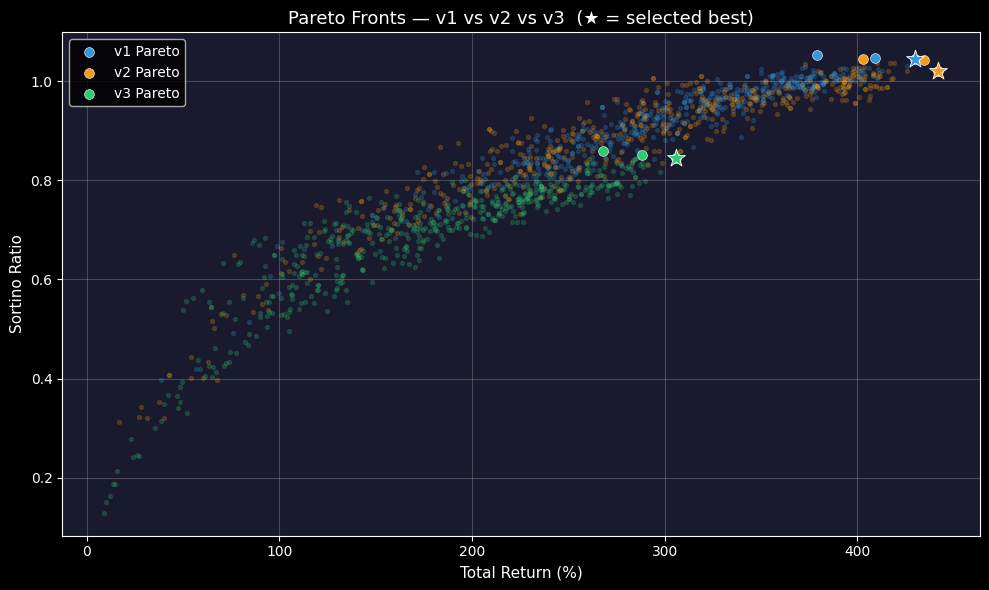

In [104]:
# ── Pareto fronts of all 3 versions on one chart ─────────────────────────────
COLORS = {'v1': '#3498db', 'v2': '#f39c12', 'v3': '#2ecc71'}

fig, ax = plt.subplots(figsize=(10, 6))
ax.set_facecolor('#1a1a2e')

for ver, study in studies.items():
    col = COLORS[ver]
    # background: all trials
    all_vals = [(t.values[0], t.values[1]) for t in study.trials
                if t.values and t.values[0] > -900]
    if all_vals:
        ax.scatter(*zip(*all_vals), c=col, s=8, alpha=0.2)
    # Pareto front
    pf_vals = [(t.values[0], t.values[1]) for t in study.best_trials]
    ax.scatter(*zip(*pf_vals), c=col, s=50, zorder=5,
               edgecolors='white', linewidths=0.4, label=f'{ver} Pareto')
    # best point
    bt = best_trials[ver]
    ax.scatter(bt.values[0], bt.values[1], c=col, s=180, marker='*',
               zorder=6, edgecolors='white', linewidths=0.6)

ax.set_xlabel('Total Return (%)', fontsize=11)
ax.set_ylabel('Sortino Ratio',    fontsize=11)
ax.set_title('Pareto Fronts — v1 vs v2 vs v3  (★ = selected best)', fontsize=13)
ax.legend(fontsize=10)
ax.yaxis.grid(True, alpha=0.2); ax.xaxis.grid(True, alpha=0.2)
fig.tight_layout(); plt.show()


## 6. Final Backtest — Optimised v1 vs v2 vs v3

In [105]:
portfolios = {}

for ver in ['v1', 'v2', 'v3']:
    p  = best_params[ver]
    print(f'Running optimised {ver} …')
    entries = compute_signals(
        close, high, low,
        bb_window                = p['bb_window'],
        bb_multiplier            = p['bb_multiplier'],
        bb_matype                = 0,
        kc_window                = p['kc_window'],
        kc_multiplier            = p['kc_multiplier'],
        kc_atr_period            = p['kc_atr_period'],
        donichan_window          = p['donichan_window'],
        osc_smoothing_period     = p['osc_smoothing_period'],
        entry_version            = ver,
        consecutive_neg_threshold= p.get('consecutive_neg_threshold', 7),
        william_vix_period       = p.get('william_vix_period',        20),
    )
    exits = compute_exits(close, high, low, atr_multiplier=p['atr_multiplier'])
    pf    = vbt.Portfolio.from_signals(
        close=close, entries=entries, exits=exits,
        freq='1d', group_by=['symbol'],
        cash_sharing=False, sl_stop=p['sl_stop'],
    )
    portfolios[ver] = pf
    n_sig = int(entries.sum().sum())
    print(f'  signals={n_sig:,}  trades={int(pf.trades.count().sum()):,}')

print('\nAll done.')


Running optimised v1 …
  signals=127,558  trades=8,194
Running optimised v2 …
  signals=43,621  trades=8,645
Running optimised v3 …
  signals=13,509  trades=5,086

All done.


## 7. Comparison — Stats Table

In [106]:
def version_stats(ver, pf):
    s = pf.sharpe_ratio().replace([np.inf, -np.inf], np.nan).dropna()
    return {
        'Version':          ver,
        'Sharpe mean':      round(s.mean(), 3),
        'Sharpe median':    round(s.median(), 3),
        'Sharpe > 0':       f'{(s > 0).sum()}/{len(s)}',
        'Sharpe > 1':       f'{(s > 1).sum()}/{len(s)}',
        'Sortino mean':     round(pf.sortino_ratio().replace([np.inf,-np.inf],np.nan).dropna().mean(), 3),
        'Calmar mean':      round(pf.calmar_ratio().replace([np.inf,-np.inf],np.nan).dropna().mean(), 3),
        'Total Ret mean':   f'{pf.total_return().mean():.1%}',
        'Total Ret median': f'{pf.total_return().median():.1%}',
        'Max DD mean':      f'{pf.max_drawdown().mean():.1%}',
        'Max DD worst':     f'{pf.max_drawdown().min():.1%}',
        'N Trades':         int(pf.trades.count().sum()),
        'Avg Trade Ret':    f'{pd.Series(pf.trades.returns.mean()).mean():.2%}',
        'Win Rate':         f'{pf.trades.win_rate().mean():.1%}',
        'Profit Factor':    round(pf.trades.profit_factor().mean(), 3),
    }

rows = [version_stats(ver, pf) for ver, pf in portfolios.items()]
# also add baseline
rows.insert(0, version_stats('baseline (v3 default)', pf_base))

comp_df = pd.DataFrame(rows).set_index('Version')
print('=== VERSION COMPARISON ===')
display(comp_df.T)


=== VERSION COMPARISON ===


Version,baseline (v3 default),v1,v2,v3
Sharpe mean,0.348,0.673,0.655,0.555
Sharpe median,0.356,0.729,0.693,0.552
Sharpe > 0,163/198,192/198,190/198,186/198
Sharpe > 1,8/198,34/198,28/198,21/198
Sortino mean,0.56,1.044,1.02,0.845
Calmar mean,0.203,0.473,0.459,0.319
Total Ret mean,79.8%,430.2%,442.1%,305.8%
Total Ret median,37.2%,254.3%,212.4%,138.8%
Max DD mean,-39.1%,-47.8%,-46.0%,-54.3%
Max DD worst,-91.8%,-92.9%,-91.5%,-83.9%


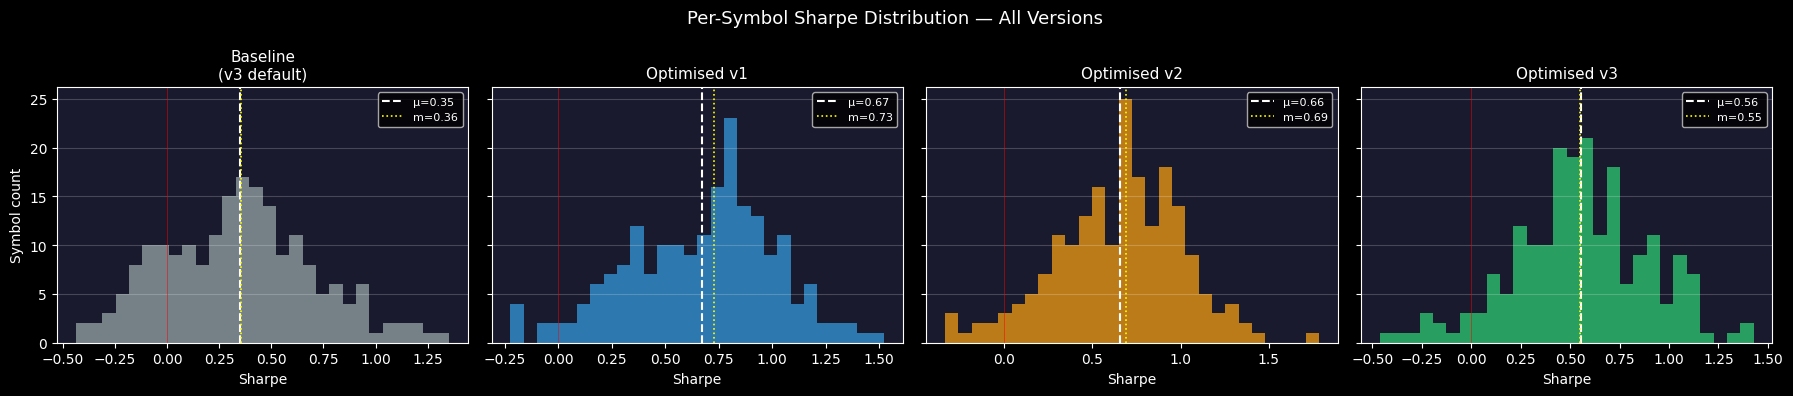

In [107]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4), sharey=True)

entries_list = [('Baseline\n(v3 default)', pf_base, '#95a5a6')] + [
    (f'Optimised {ver}', portfolios[ver], COLORS[ver])
    for ver in ['v1', 'v2', 'v3']
]

for ax, (name, pf, col) in zip(axes, entries_list):
    sv = pf.sharpe_ratio().replace([np.inf, -np.inf], np.nan).dropna()
    ax.set_facecolor('#1a1a2e')
    ax.hist(sv, bins=28, color=col, alpha=0.75, edgecolor='none')
    ax.axvline(sv.mean(),   color='white',  lw=1.5, ls='--',
               label=f'μ={sv.mean():.2f}')
    ax.axvline(sv.median(), color='yellow', lw=1.2, ls=':',
               label=f'm={sv.median():.2f}')
    ax.axvline(0, color='red', lw=0.7, alpha=0.5)
    ax.set_title(name, fontsize=11); ax.set_xlabel('Sharpe')
    ax.legend(fontsize=8); ax.yaxis.grid(True, alpha=0.2)

axes[0].set_ylabel('Symbol count')
fig.suptitle('Per-Symbol Sharpe Distribution — All Versions', fontsize=13)
fig.tight_layout(); plt.show()


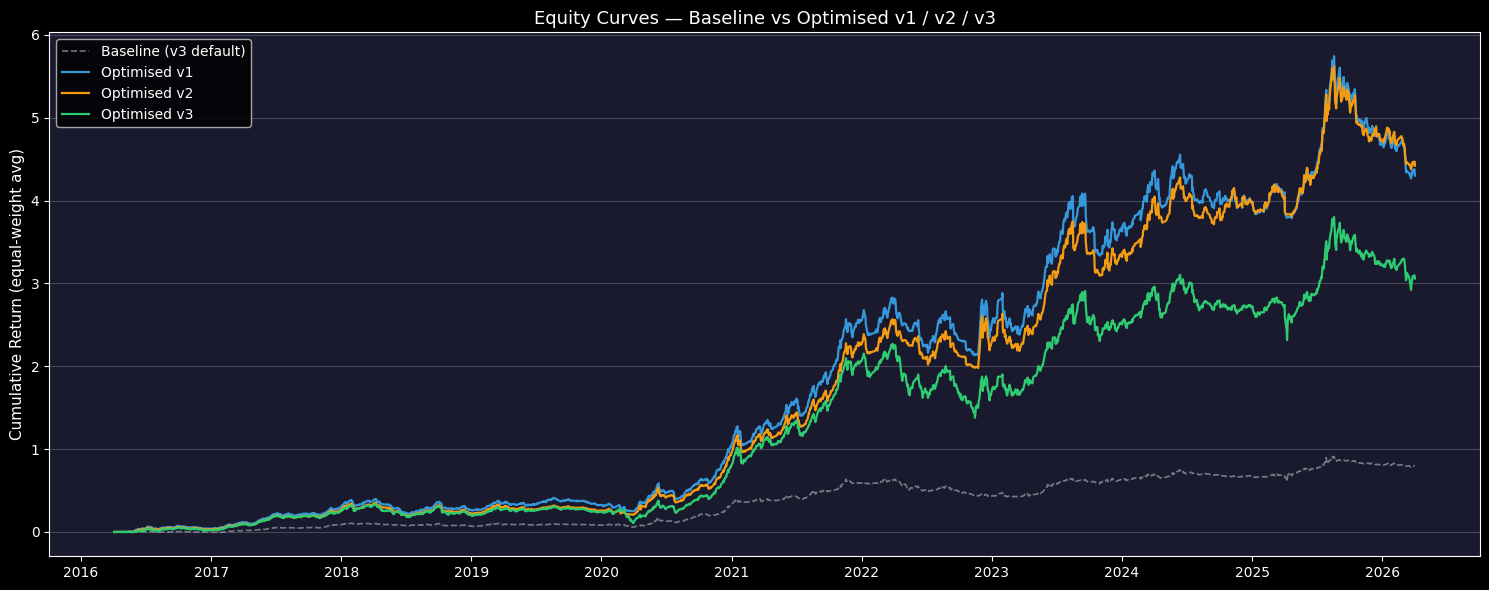

In [108]:
fig, ax = plt.subplots(figsize=(15, 6))
ax.set_facecolor('#1a1a2e')

ax.plot(*zip(*[(d, v) for d, v in zip(
    pf_base.cumulative_returns().mean(axis=1).index,
    pf_base.cumulative_returns().mean(axis=1).values
)]), color='#95a5a6', lw=1.2, ls='--', label='Baseline (v3 default)', alpha=0.7)

for ver, pf in portfolios.items():
    cum = pf.cumulative_returns().mean(axis=1)
    ax.plot(cum.index, cum.values, label=f'Optimised {ver}',
            color=COLORS[ver], lw=1.6)

ax.set_ylabel('Cumulative Return (equal-weight avg)', fontsize=11)
ax.set_title('Equity Curves — Baseline vs Optimised v1 / v2 / v3', fontsize=13)
ax.legend(fontsize=10); ax.yaxis.grid(True, alpha=0.2)
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
fig.tight_layout(); plt.show()


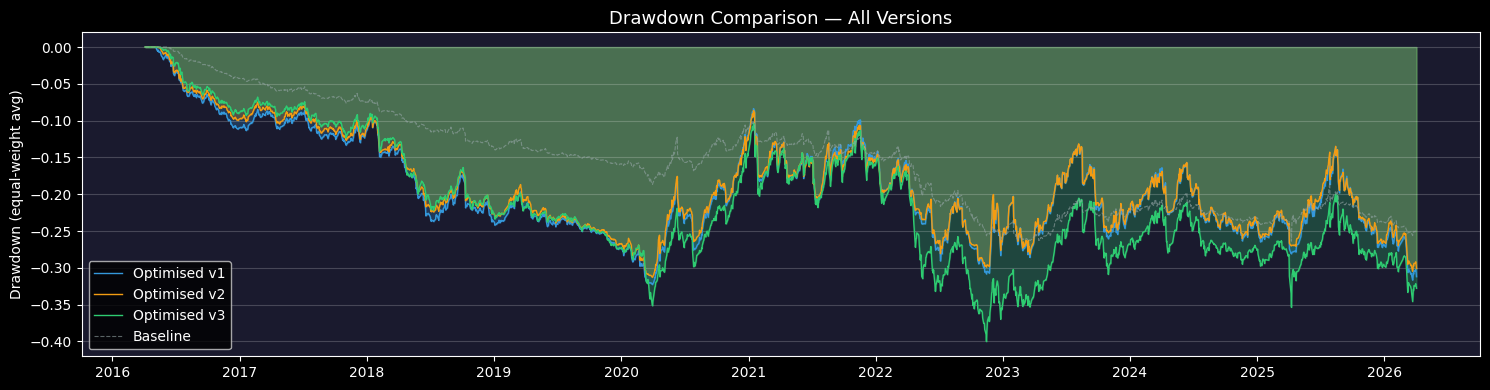

In [109]:
fig, ax = plt.subplots(figsize=(15, 4))
ax.set_facecolor('#1a1a2e')

for ver, pf in portfolios.items():
    dd = pf.drawdown().mean(axis=1)
    ax.fill_between(dd.index, dd.values, 0,
                    alpha=0.25, color=COLORS[ver])
    ax.plot(dd.index, dd.values, color=COLORS[ver], lw=1.0, label=f'Optimised {ver}')

# baseline
dd_base = pf_base.drawdown().mean(axis=1)
ax.plot(dd_base.index, dd_base.values, color='#95a5a6', lw=0.8, ls='--',
        alpha=0.6, label='Baseline')

ax.set_ylabel('Drawdown (equal-weight avg)')
ax.set_title('Drawdown Comparison — All Versions', fontsize=13)
ax.legend(fontsize=10); ax.yaxis.grid(True, alpha=0.2)
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
fig.tight_layout(); plt.show()


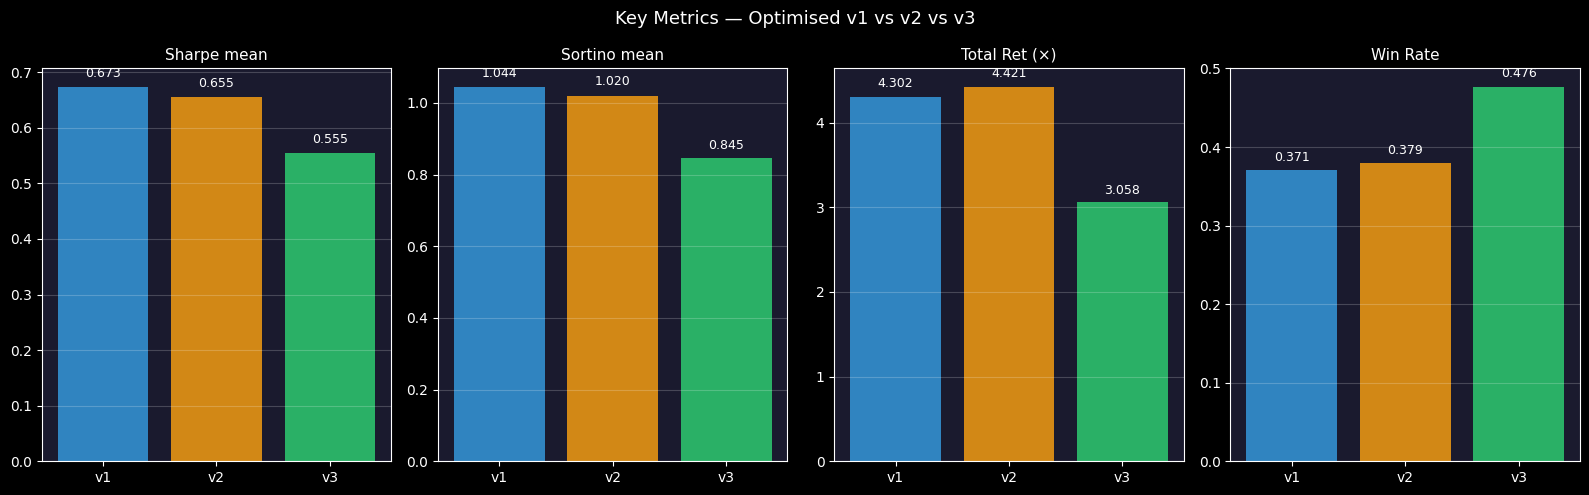

In [110]:
# ── grouped bar chart: Sharpe mean, Sortino mean, Total Ret mean ──────────────
versions  = ['v1', 'v2', 'v3']
metrics   = {
    'Sharpe mean':  [portfolios[v].sharpe_ratio().replace([np.inf,-np.inf],np.nan).dropna().mean()
                     for v in versions],
    'Sortino mean': [portfolios[v].sortino_ratio().replace([np.inf,-np.inf],np.nan).dropna().mean()
                     for v in versions],
    'Total Ret (×)': [portfolios[v].total_return().mean() for v in versions],
    'Win Rate':     [portfolios[v].trades.win_rate().mean() for v in versions],
}

x   = np.arange(len(versions))
fig, axes = plt.subplots(1, 4, figsize=(16, 5))

for ax, (metric, vals) in zip(axes, metrics.items()):
    colors = [COLORS[v] for v in versions]
    bars   = ax.bar(versions, vals, color=colors, edgecolor='none', alpha=0.85)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                val + abs(val) * 0.02,
                f'{val:.3f}', ha='center', va='bottom', fontsize=9)
    ax.set_title(metric, fontsize=11)
    ax.axhline(0, color='white', lw=0.6, alpha=0.5)
    ax.yaxis.grid(True, alpha=0.2)
    ax.set_facecolor('#1a1a2e')

fig.suptitle('Key Metrics — Optimised v1 vs v2 vs v3', fontsize=13)
fig.tight_layout(); plt.show()


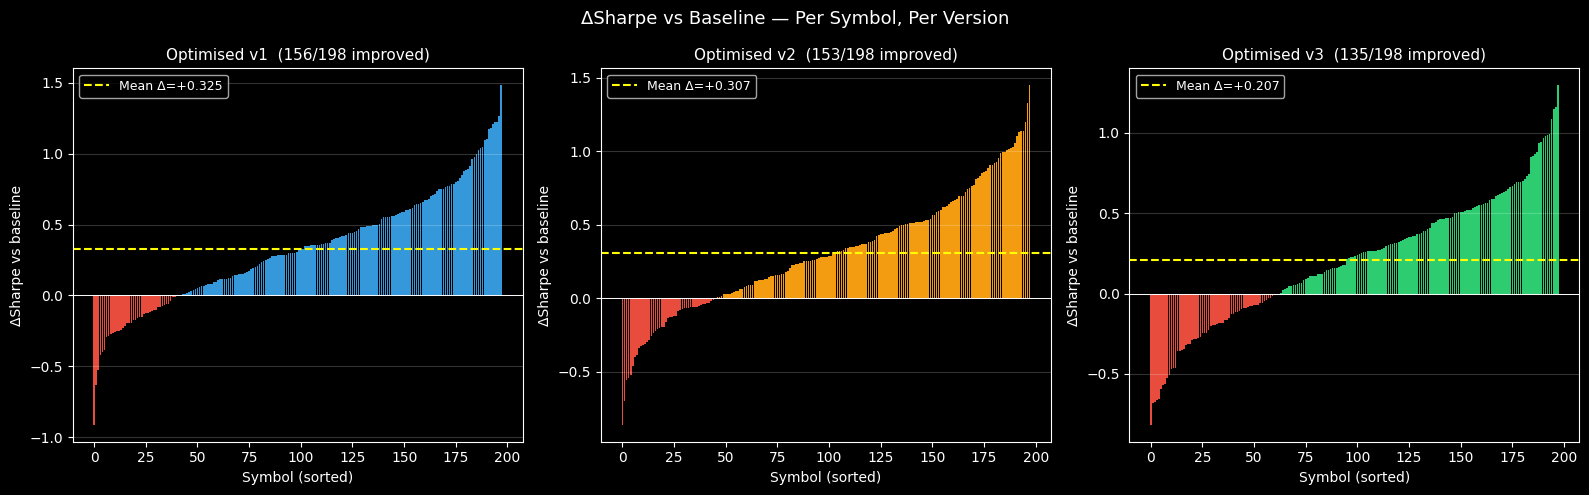

In [111]:
# ── ΔSharpe vs baseline for each version ─────────────────────────────────────
sharpe_base_sym = pf_base.sharpe_ratio().replace([np.inf,-np.inf], np.nan)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, ver in zip(axes, ['v1', 'v2', 'v3']):
    delta = (portfolios[ver].sharpe_ratio().replace([np.inf,-np.inf], np.nan)
             - sharpe_base_sym).dropna().sort_values()
    bar_colors = [COLORS[ver] if v >= 0 else '#e74c3c' for v in delta]
    ax.bar(range(len(delta)), delta.values, color=bar_colors, edgecolor='none')
    ax.axhline(0, color='white', lw=0.7)
    ax.axhline(delta.mean(), color='yellow', lw=1.5, ls='--',
               label=f'Mean Δ={delta.mean():+.3f}')
    improved = (delta > 0).sum()
    ax.set_title(f'Optimised {ver}  ({improved}/{len(delta)} improved)', fontsize=11)
    ax.set_xlabel('Symbol (sorted)'); ax.set_ylabel('ΔSharpe vs baseline')
    ax.legend(fontsize=9); ax.yaxis.grid(True, alpha=0.2)

fig.suptitle('ΔSharpe vs Baseline — Per Symbol, Per Version', fontsize=13)
fig.tight_layout(); plt.show()


In [112]:
# ── final scorecard ───────────────────────────────────────────────────────────
print('=' * 62)
print('  FINAL SCORECARD — OPTIMISED v1 / v2 / v3')
print('=' * 62)
print(f'  {"Version":<12}  {"Sharpe μ":>9}  {"Sortino μ":>10}  {"Total Ret μ":>12}  {"Win Rate":>9}')
print('  ' + '-' * 58)

scores = []
for ver, pf in portfolios.items():
    sh = pf.sharpe_ratio().replace([np.inf,-np.inf],np.nan).dropna().mean()
    so = pf.sortino_ratio().replace([np.inf,-np.inf],np.nan).dropna().mean()
    tr = pf.total_return().mean()
    wr = pf.trades.win_rate().mean()
    scores.append((ver, sh, so, tr, wr))
    print(f'  {ver:<12}  {sh:>9.3f}  {so:>10.3f}  {tr:>12.1%}  {wr:>9.1%}')

print('=' * 62)
best_ver = max(scores, key=lambda x: x[1])
print(f'\n  Best Sharpe  → {best_ver[0]}  ({best_ver[1]:.3f})')
best_ret = max(scores, key=lambda x: x[3])
print(f'  Best Return  → {best_ret[0]}  ({best_ret[3]:.1%})')
best_so  = max(scores, key=lambda x: x[2])
print(f'  Best Sortino → {best_so[0]}  ({best_so[2]:.3f})')


  FINAL SCORECARD — OPTIMISED v1 / v2 / v3
  Version        Sharpe μ   Sortino μ   Total Ret μ   Win Rate
  ----------------------------------------------------------
  v1                0.673       1.044        430.2%      37.1%
  v2                0.655       1.020        442.1%      37.9%
  v3                0.555       0.845        305.8%      47.6%

  Best Sharpe  → v1  (0.673)
  Best Return  → v2  (442.1%)
  Best Sortino → v1  (1.044)


## 8. Save Results to HDF5

In [113]:
h5_file   = '../backend/assets/backtest_results_005.h5'
close_syms = set(close.columns)

# ── trades ────────────────────────────────────────────────────────────────────
trades_df = pf_opt.trades.records_readable.copy()

def extract_symbol(col):
    if isinstance(col, tuple):
        return next((v for v in col if v in close_syms), str(col))
    return col if isinstance(col, str) and col in close_syms else str(col)

trades_df['symbol']          = trades_df['Column'].apply(extract_symbol)
trades_df['Entry Timestamp'] = pd.to_datetime(trades_df['Entry Timestamp']).dt.strftime('%Y-%m-%d')
trades_df['Exit Timestamp']  = pd.to_datetime(trades_df['Exit Timestamp']).dt.strftime('%Y-%m-%d')

# ── per-symbol stats ──────────────────────────────────────────────────────────
all_metrics = list(pf_opt.metrics.keys())
metrics_ok  = [m for m in all_metrics if m not in ('profit_factor', 'expectancy')]
stats_df    = pf_opt.stats(metrics=metrics_ok, agg_func=None).reset_index().set_index('symbol')

# ── best params ───────────────────────────────────────────────────────────────
params_df = pd.Series(best, name='value').to_frame()

trades_df.to_hdf(h5_file, key='trades',     mode='w')
stats_df.to_hdf(h5_file,  key='stats',      mode='a')
params_df.to_hdf(h5_file, key='best_params', mode='a')

print(f'Saved {len(trades_df):,} trades  →  {h5_file}')
print(f'Saved stats for {len(stats_df)} symbols')
print(f'Saved best params ({len(best)} keys)')

trades_df.head()

Saved 8,521 trades  →  ../backend/assets/backtest_results_005.h5
Saved stats for 198 symbols
Saved best params (12 keys)


,Exit Trade Id,Column,Size,Entry Timestamp,Avg Entry Price,Entry Fees,Exit Timestamp,Avg Exit Price,Exit Fees,PnL,Return,Direction,Status,Position Id,symbol
0,0,"(3.3, 10, AAA)",9.860704,2016-05-04,10.141264,0.0,2016-09-13,15.317534,0.0,51.041670,0.510417,Long,Closed,0,AAA
1,1,"(3.3, 10, AAA)",9.254383,2016-09-28,16.321096,0.0,2016-11-02,15.317534,0.0,-9.287346,-0.061489,Long,Closed,1,AAA
2,2,"(3.3, 10, AAA)",8.975823,2016-11-21,15.792906,0.0,2016-12-01,14.894981,0.0,-8.059610,-0.056856,Long,Closed,2,AAA
3,3,"(3.3, 10, AAA)",9.964995,2017-01-06,13.416436,0.0,2017-01-18,12.731924,0.0,-6.821160,-0.051020,Long,Closed,3,AAA
4,4,"(3.3, 10, AAA)",9.817209,2017-02-08,12.923587,0.0,2017-10-30,17.860754,0.0,48.469202,0.382028,Long,Closed,4,AAA
